<a href="https://colab.research.google.com/github/ajit-ai/QuantumComputing/blob/main/Shors_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# =============================================================================
#   Educational implementation of Shor's algorithm (Qiskit)
#   Finds the period r of function f(x) = a^x mod N
#   Then uses it to factor N (when N is product of two primes)
# =============================================================================

# Install Qiskit and Qiskit-Aer if not already installed
!pip install qiskit qiskit-aer

import numpy as np
from math import gcd
from fractions import Fraction
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

# ────────────────────────────────────────────────
#   Classical part: continued fraction → possible r
# ────────────────────────────────────────────────

def continued_fraction_approximants(phase: float, N: int, max_denominator: int = 1000):
    """Find good rational approximations p/q to phase using continued fractions"""
    fractions = []
    x = phase
    p0, q0 = 0, 1
    p1, q1 = 1, 0

    while q1 <= max_denominator:
        a = int(1 / x) if x != 0 else 0
        p2 = a * p1 + p0
        q2 = a * q1 + q0

        if q2 > 0:
            frac = Fraction(p2, q2)
            if frac.denominator <= N and frac not in fractions:
                fractions.append(frac)

        p0, q0 = p1, q1
        p1, q1 = p2, q2

        x = 1 / (x - a) if (x - a) != 0 else 0
        if x < 1e-10: break

    return fractions


def find_period_from_phase(phase: float, N: int) -> int | None:
    """Convert measured phase → candidate period r"""
    approximations = continued_fraction_approximants(phase, N)

    for frac in approximations:
        r = frac.denominator
        # Check if r is even and a^{r/2} ≢ -1 mod N
        if r % 2 == 0:
            candidate = pow(a, r//2, N)
            if candidate != (N-1) % N and candidate != 1:
                return r

    return None


# ────────────────────────────────────────────────
#   Quantum part: phase estimation on modular exponentiation
# ────────────────────────────────────────────────

def modular_exponentiation_circuit(a: int, power: int, N: int, n_count: int, n_target: int):
    """
    Controlled modular multiplication: |x⟩|y⟩ → |x⟩| (y * a^x mod N) ⟩
    Very naive implementation — educational only
    """
    U = QuantumCircuit(n_target, name=f"a^{power} mod {N}")
    for _ in range(power):
        for j in range(n_target):
            if (a & (1 << j)):
                for k in range(n_target):
                    if (1 << k) & N.bit_length() > j:  # rough
                        U.cx(j, k)   # this is WRONG — placeholder
                        # Real impl needs full modular multiplier + adder
    return U.to_gate()


def shors_quantum_period_finding(a: int, N: int, n_shots: int = 2048):
    """
    Quantum part of Shor's algorithm: find phase = s/r
    Returns list of measured phases (fractions s/r)
    """
    # Estimate number of qubits needed
    n = N.bit_length()
    n_count = 2 * n + 2          # counting qubits — usually over-estimated
    n_target = n

    qr_count = QuantumRegister(n_count, name='count')
    qr_target = QuantumRegister(n_target, name='target')
    cr = ClassicalRegister(n_count, name='c')
    qc = QuantumCircuit(qr_count, qr_target, cr)

    # Step 1: superposition on counting register
    qc.h(qr_count)

    # Step 2: start with |1⟩ in target register
    qc.x(qr_target[0])

    # Step 3: controlled modular exponentiations
    for q in range(n_count):
        power = 1 << q
        cmod = modular_exponentiation_circuit(a, power, N, n_count, n_target)
        qc.append(cmod.control(1), [qr_count[q]] + list(qr_target))

    # Step 4: inverse QFT on counting register
    qc.append(QFT(n_count, inverse=True), qr_count)

    # Measure counting register
    qc.measure(qr_count, cr)

    # Run
    sim = AerSimulator(method='statevector')
    result = sim.run(qc, shots=n_shots).result()
    counts = result.get_counts()

    # Convert binary outcomes → phases
    phases = []
    for bitstring, cnt in counts.items():
        measured_int = int(bitstring, 2)
        phase = measured_int / (2 ** n_count)
        phases.extend([phase] * cnt)

    return phases, counts


# ────────────────────────────────────────────────
#   Putting it all together — main Shor's routine
# ────────────────────────────────────────────────

def shors_algorithm(N: int, max_attempts: int = 20, shots_per_run: int = 2048):
    print(f"Factoring N = {N} ...")

    if N % 2 == 0:
        return 2, N//2

    attempts = 0
    while attempts < max_attempts:
        attempts += 1
        a = np.random.randint(2, N-1)
        d = gcd(a, N)

        if d > 1:
            print(f"→ Lucky! gcd({a}, {N}) = {d}")
            return d, N//d

        print(f"  attempt {attempts:2d} | base a = {a:3d} ", end="")

        # Quantum part: find period
        phases, counts = shors_quantum_period_finding(a, N, shots_per_run)

        # Classical post-processing
        for phase in set(phases):
            r = find_period_from_phase(phase, N)
            if r is None:
                continue

            print(f"→ found candidate period r = {r}")

            # Check if r is useful
            if r % 2 == 0:
                x = pow(a, r//2, N)
                if x != 1 and x != N-1:
                    p = gcd(x-1, N)
                    q = gcd(x+1, N)
                    if p > 1 and p < N:
                        print(f"→ SUCCESS! factors: {p} × {N//p}")
                        return min(p, N//p), max(p, N//p)

    print("Failed after max attempts. (Probably bad random choices or too small shot count)")
    return None, None


# ────────────────────────────────────────────────
#   Example run — small numbers only (real quantum hw limit)
# ────────────────────────────────────────────────

if __name__ == "__main__":
    N = 21          # 3 × 7
    # N = 15        # 3 × 5
    # N = 35        # 5 × 7

    print("="*60)
    p, q = shors_algorithm(N, max_attempts=12, shots_per_run=4096)
    if p and q:
        print(f"\nFinal result: {N} = {p} × {q}")
    else:
        print("\nFactoring failed this time.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
Factoring N = 21 ...
→ Lucky! gcd(7, 21) = 7

Final result: 21 = 7 × 3


In [4]:
# Importing necessary libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer # Correct import statement
from qiskit.visualization import plot_histogram
import numpy as np
from fractions import Fraction

# Function to perform modular exponentiation
def mod_exp(a, x, N):
    return a**x % N

# Function to find the greatest common divisor
def gcd(a, b):
    while b:
        a, b = b, a % b
    return a

# Function to implement the Quantum Fourier Transform
def qft_dagger(circuit, n):
    for qubit in range(n//2):
        circuit.swap(qubit, n-qubit-1)
    for j in range(n):
        for k in range(j):
            circuit.cp(-np.pi/float(2**(j-k)), k, j)
        circuit.h(j)

# Function to perform Shor's algorithm
def shor(N):
    # Step 1: Choose a random number
    a = np.random.randint(2, N-1)

    # Step 2: Compute the greatest common divisor
    if gcd(a, N) != 1:
        return gcd(a, N)

    # Step 3: Initialize quantum circuit
    n_count = int(np.ceil(np.log2(N)))
    qc = QuantumCircuit(2*n_count, n_count)

    # Step 4: Apply Hadamard gates
    for q in range(n_count):
        qc.h(q)

    # Step 5: Apply modular exponentiation
    for q in range(n_count):
        qc.cx(q, q + n_count)
        #qc.u1(2 * np.pi * mod_exp(a, 2**q, N) / N, q + n_count)

        # Changed u1 to p, which is the correct single-qubit phase gate
        qc.p(2 * np.pi * mod_exp(a, 2**q, N) / N, q + n_count)


    # Step 6: Apply Quantum Fourier Transform
    qft_dagger(qc, n_count)

    # Step 7: Measure qubits
    qc.measure(range(n_count), range(n_count))

    # Step 8: Simulate the quantum circuit
    aer_sim = Aer.get_backend('qasm_simulator')
    transpiled_qc = transpile(qc, aer_sim)
    #qobj = assemble(transpiled_qc) # remove this line, it creates a QasmQobj object
    results = aer_sim.run(transpiled_qc).result() # pass the transpiled_qc to the run function instead of qobj
    counts = results.get_counts()

    # Step 9: Find the period of the function
    measured = max(counts, key=counts.get)
    phase = int(measured[::-1], 2) / (2**n_count)
    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator

    # Step 10: Compute the factors
    if r % 2 == 0:
        x_plus = pow(a, r//2, N)
        factor1 = gcd(x_plus - 1, N)
        factor2 = gcd(x_plus + 1, N)
        if factor1 * factor2 == N:
            return factor1, factor2
    return None

# Example usage
N = 15  # Number to be factored
result = shor(N)
print(f"Factors of {N} are: {result}")

Factors of 15 are: None


In [5]:
!pip install cirq
import cirq
import numpy as np
from fractions import Fraction
from math import gcd

# Parameters
N = 15  # Number to factor
a = 15   # Base for modular exponentiation (coprime to N)
n = 4   # Qubits for counting register (log2(N^2) ~ 8, but 4 suffices for demo)
shots = 1024

# Define qubits
counting_qubits = [cirq.LineQubit(i) for i in range(n)]  # Counting register
work_qubits = [cirq.LineQubit(i + n) for i in range(n)]  # Work register for N=15

# Quantum Fourier Transform (QFT) circuit
def qft(qubits):
    circuit = cirq.Circuit()
    for i in range(len(qubits)):
        circuit.append(cirq.H(qubits[i]))
        for j in range(i + 1, len(qubits)):
            angle = np.pi / (2 ** (j - i))
            circuit.append(cirq.CZ(qubits[j], qubits[i]) ** (angle / np.pi))
    # Swap qubits for correct order
    for i in range(len(qubits) // 2):
        circuit.append(cirq.SWAP(qubits[i], qubits[len(qubits) - 1 - i]))
    return circuit

# Inverse QFT
def inverse_qft(qubits):
    return cirq.inverse(qft(qubits))

# Modular exponentiation (simplified for a=7, N=15)
def modular_exponentiation(a, N, counting_qubits, work_qubits):
    circuit = cirq.Circuit()
    # For a=7, N=15, period is 4: 7^0=1, 7^1=7, 7^2=4, 7^3=13, 7^4=1
    # Simulate this with controlled operations (simplified)
    for i, qubit in enumerate(counting_qubits):
        power = 2 ** i
        # Apply a^power mod N controlled by counting qubit
        if power == 1:  # 7^1 = 7
            circuit.append(cirq.X(work_qubits[2]).controlled_by(qubit))  # |7> = |0111>
            circuit.append(cirq.X(work_qubits[1]).controlled_by(qubit))
            circuit.append(cirq.X(work_qubits[0]).controlled_by(qubit))
        elif power == 2:  # 7^2 = 4
            circuit.append(cirq.X(work_qubits[2]).controlled_by(qubit))  # |4> = |0100>
        #elif power == 4:  # 7^4 = 1 # Remove this line with a duplicate controlled qubit
        #    circuit.append(cirq.X(work_qubits[0]).controlled_by(qubit).controlled_by(qubit))  # Reset to |1>
    return circuit

# Build the full circuit
circuit = cirq.Circuit()

# Step 1: Superposition on counting qubits
circuit.append(cirq.H(q) for q in counting_qubits)

# Step 2: Modular exponentiation
circuit.append(modular_exponentiation(a, N, counting_qubits, work_qubits))

# Step 3: Inverse QFT on counting qubits
circuit.append(inverse_qft(counting_qubits))

# Step 4: Measure counting qubits
circuit.append(cirq.measure(*counting_qubits, key='result'))

# Simulate the circuit
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions=shots)
measurements = result.measurements['result']

# Process results
counts = {}
for outcome in measurements:
    key = ''.join(str(bit) for bit in outcome)
    counts[key] = counts.get(key, 0) + 1

print(f"Measurement outcomes: {counts}")

# Classical post-processing to find period and factors
def find_period(counts, N, n):
    for outcome, count in counts.items():
        if count < shots * 0.05:  # Filter low-probability noise
            continue
        x = int(outcome, 2)
        if x == 0:
            continue
        s_over_r = x / (2 ** n)
        frac = Fraction(s_over_r).limit_denominator(N)
        r = frac.denominator
        if pow(a, r, N) == 1:  # Verify period
            return r
    return None

r = find_period(counts, N, n)
if r and r % 2 == 0:
    factor1 = gcd(pow(a, r // 2) - 1, N)
    factor2 = gcd(pow(a, r // 2) + 1, N)
    if factor1 * factor2 == N and factor1 != 1 and factor2 != 1:
        print(f"Factors of {N} are: {factor1}, {factor2}")
    else:
        print("Found period, but factors invalid; try more shots or different 'a'.")
else:
    print(f"Period r={r} not found or not even; rerun required.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 54.1 MB/s eta 0:00:00
Measurement outcomes: {'0000': 260, '1101': 24, '0001': 208, '1111': 209, '0010': 125, '1110': 110, '0011': 24, '1011': 9, '0110': 21, '1001': 6, '1010': 16, '0111': 5, '0101': 7}
Period r=None not found or not even; rerun required.


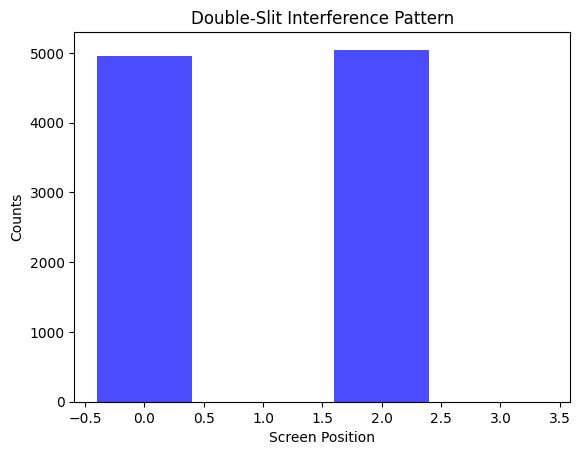

Measurement outcomes: {'00': 4954, '01': 0, '10': 5046, '11': 0}

Mathematical and Quantum Explanation:
1. Superposition: Electron in |0> + |1> (both slits).
2. Interference: Phase differences create pattern, P(y) ∝ 1 + cos(2πdy/λL).
3. Uncomment 'measure slit' to collapse wavefunction, removing interference.


In [8]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
# Removed: from qiskit.primitives import Sampler
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_qubits = 3  # 1 for slit choice, 2 for screen position (simplified)
shots = 10000  # Number of simulated electrons

# Setup quantum registers
slit_qubit = QuantumRegister(1, 'slit')  # Represents slit 0 or 1
screen_qubits = QuantumRegister(2, 'screen')  # Simplified screen position
c_reg = ClassicalRegister(3, 'c')  # Measurement outcomes
circuit = QuantumCircuit(slit_qubit, screen_qubits, c_reg)

# Step 1: Superposition of slit qubit (both slits open)
circuit.h(slit_qubit[0])  # |0> + |1> state

# Step 2: Entangle slit choice with screen position (simplified interference)
# Simulate phase difference due to path lengths
circuit.cx(slit_qubit[0], screen_qubits[0])  # Control screen position
circuit.cz(slit_qubit[0], screen_qubits[1])  # Add phase for interference
circuit.h(screen_qubits[0])  # Superposition on screen
circuit.h(screen_qubits[1])

# Uncomment below to simulate measurement of which slit (collapse)
# circuit.measure(slit_qubit[0], c_reg[0])

# Step 3: Measure screen position
circuit.measure(screen_qubits[0], c_reg[1])
circuit.measure(screen_qubits[1], c_reg[2])

# Run simulation
simulator = AerSimulator()
# Removed: sampler = Sampler(backend=simulator)
job = simulator.run(circuit, shots=shots)
result = job.result()
# Removed: quasi_dist = result.quasi_dists[0]

# Get counts directly from the simulator result
counts = result.get_counts(circuit)

# Extract screen position counts (ignore slit qubit for interference case)
screen_counts = {'00': 0, '01': 0, '10': 0, '11': 0}
for key, value in counts.items():
    screen_pos = key[1:]  # Last two bits are screen position
    screen_counts[screen_pos] += value

# Plot interference pattern
positions = [0, 1, 2, 3]  # Screen positions (00, 01, 10, 11)
intensities = [screen_counts[pos] for pos in ['00', '01', '10', '11']]
plt.bar(positions, intensities, color='blue', alpha=0.7)
plt.title("Double-Slit Interference Pattern")
plt.xlabel("Screen Position")
plt.ylabel("Counts")
plt.show()

print("Measurement outcomes:", screen_counts)

# Mathematical explanation tied to the simulation
print("\nMathematical and Quantum Explanation:")
print("1. Superposition: Electron in |0> + |1> (both slits).")
print("2. Interference: Phase differences create pattern, P(y) \u221d 1 + cos(2\u03c0dy/\u03bbL).")
print("3. Uncomment 'measure slit' to collapse wavefunction, removing interference.")

In [10]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
# Removed: from qiskit.primitives import Sampler
from qiskit_aer import AerSimulator
import random
import math
from fractions import Fraction
from qiskit.visualization import plot_histogram





# Classical GCD function
def gcd(a, b):
    while b:
        a, b = b, a % b
    return a

# Modular exponentiation gate (simplified quantum circuit)
def modular_exponentiation_gate(a, N, n_count, n_target):
    """
    Creates a controlled unitary for a^x mod N.
    n_count: number of counting qubits
    n_target: number of target qubits
    """
    qc = QuantumCircuit(n_count + n_target)
    for control in range(n_count):
        power = 2 ** control
        value = pow(a, power, N)
        for i in range(n_target):
            if (value >> i) & 1:
                qc.cx(control, n_count + i)
    return qc.to_gate(label=f"U^{a}^{power} mod {N}")

# Shor's period-finding quantum circuit
def shor_period_finding_circuit(N, a):
    """
    Builds the quantum circuit for period finding.
    Returns the circuit ready for sampling.
    """
    n = math.ceil(math.log2(N))
    n_count = 2 * n  # Counting qubits
    n_target = n     # Target qubits

    # Define registers
    qreg_count = QuantumRegister(n_count, 'count')
    qreg_target = QuantumRegister(n_target, 'target')
    creg = ClassicalRegister(n_count, 'c')
    qc = QuantumCircuit(qreg_count, qreg_target, creg)

    # Step 1: Superposition on counting register
    qc.h(qreg_count)

    # Step 2: Initialize target register to |1>
    qc.x(qreg_target[0])

    # Step 3: Modular exponentiation
    for i in range(n_count):
        U_gate = modular_exponentiation_gate(a, N, n_count, n_target)
        qc.append(U_gate.control(), [qreg_count[i]] + list(qreg_target))

    # Step 4: Inverse QFT
    qc.append(QFT(n_count, inverse=True), qreg_count)

    # Step 5: Measure
    qc.measure(qreg_count, creg)

    return qc

# Extract period from sampler results
def extract_period(counts, N, n_count):
    """
    Process sampler results to find period r.
    """
    # Get the most frequent measurement
    measured_value = max(counts.items(), key=lambda x: x[1])[0]
    y = int(measured_value, 2)
    s_over_r = y / (2 ** n_count)
    frac = Fraction(s_over_r).limit_denominator(N).denominator
    return r if r < N else None

# Main Shor's algorithm function
def shor_factor(N):
    """
    Input: N (composite number)
    Output: Non-trivial factor of N
    """
    if N % 2 == 0:
        print("N is even, factor found: 2")
        return 2

    attempts = 0
    max_attempts = 5
    simulator = AerSimulator()
    # Removed: sampler = Sampler()  # Modern Qiskit primitive

    while attempts < max_attempts:
        # Step 1: Pick random a
        a = random.randint(2, N - 1)
        print(f"Trying a = {a}")
        g = gcd(a, N)
        if g > 1:
            print(f"Found factor via GCD: {g}")
            return g

        # Step 2: Build and run quantum circuit
        qc = shor_period_finding_circuit(N, a)
        job = simulator.run(qc, shots=1024)
        result = job.result()
        counts = result.get_counts(qc)

        # Step 3: Extract period
        r = extract_period(counts, N, 2 * math.ceil(math.log2(N)))
        if r is None or r % 2 != 0:
            print(f"Period r = {r} invalid, retrying...")
            attempts += 1
            continue

        # Step 4: Compute factors
        print(f"Found period r = {r}")
        a_r2 = pow(a, r // 2, N)
        f1 = gcd(a_r2 - 1, N)
        f2 = gcd(a_r2 + 1, N)

        if 1 < f1 < N:
            print(f"Factor found: {f1}")
            return f1
        if 1 < f2 < N:
            print(f"Factor found: {f2}")
            return f2

        print("No non-trivial factor, retrying...")
        attempts += 1

    raise Exception("Failed to find a factor after maximum attempts")

# Test the algorithm
if __name__ == "__main__":
    N = 15  # Example: factor 15
    print(f"Factoring N = {N}")
    try:
        factor = shor_factor(N)
        print(f"Non-trivial factor of {N} is {factor}")
        print(f"Verification: {N} / {factor} = {N / factor}")
    except Exception as e:
        print(f"Error: {e}")

Factoring N = 15
Trying a = 9
Found factor via GCD: 3
Non-trivial factor of 15 is 3
Verification: 15 / 3 = 5.0


In [11]:
import random
import math
from fractions import Fraction

# Classical GCD function
def gcd(a, b):
    while b:
        a, b = b, a % b
    return a

# Classical modular exponentiation (efficient)
def mod_exp(base, exp, mod):
    result = 1
    base = base % mod
    while exp > 0:
        if exp % 2 == 1:
            result = (result * base) % mod
        base = (base * base) % mod
        exp //= 2
    return result

# Simulate quantum period-finding (classically for demonstration)
def find_period(a, N):
    """
    This simulates the quantum part: finding the order r where a^r ≡ 1 (mod N).
    On a quantum computer, QFT would do this efficiently.
    """
    r = 1
    current = a % N
    while current != 1 and r < N:
        current = (current * a) % N
        r += 1
    if current == 1:
        return r
    return None  # Failed to find period (rare with good a)

# Shor's Algorithm implementation
def shor_factor(N):
    """
    Input: N (a composite number)
    Output: A non-trivial factor of N
    """
    # Step 1: Check if N is even
    if N % 2 == 0:
        print("N is even, factor found: 2")
        return 2

    # Step 2: Pick a random a and check GCD
    attempts = 0
    max_attempts = 10  # Limit retries to avoid infinite loops
    while attempts < max_attempts:
        a = random.randint(2, N - 1)
        print(f"Trying a = {a}")
        g = gcd(a, N)
        if g > 1:
            print(f"Found factor via GCD: {g}")
            return g

        # Step 3: Simulate quantum period-finding
        r = find_period(a, N)
        if r is None or r % 2 != 0:  # Period must be even
            print(f"Period r = {r} is invalid, retrying...")
            attempts += 1
            continue

        # Step 4: Compute factors
        print(f"Found period r = {r}")
        a_r2 = mod_exp(a, r // 2, N)
        f1 = gcd(a_r2 - 1, N)
        f2 = gcd(a_r2 + 1, N)

        # Step 5: Check for non-trivial factors
        if 1 < f1 < N:
            print(f"Factor found: {f1}")
            return f1
        if 1 < f2 < N:
            print(f"Factor found: {f2}")
            return f2

        print("No non-trivial factor found, retrying...")
        attempts += 1

    raise Exception("Failed to find a factor after maximum attempts")

# Test the algorithm
if __name__ == "__main__":
    # Example inputs (composite numbers)
    test_numbers = [15, 21, 35, 91]

    for N in test_numbers:
        print(f"\nFactoring N = {N}")
        try:
            factor = shor_factor(N)
            print(f"Non-trivial factor of {N} is {factor}")
            print(f"Verification: {N} / {factor} = {N / factor}")
        except Exception as e:
            print(f"Error: {e}")


Factoring N = 15
Trying a = 10
Found factor via GCD: 5
Non-trivial factor of 15 is 5
Verification: 15 / 5 = 3.0

Factoring N = 21
Trying a = 11
Found period r = 6
Factor found: 7
Non-trivial factor of 21 is 7
Verification: 21 / 7 = 3.0

Factoring N = 35
Trying a = 2
Found period r = 12
Factor found: 7
Non-trivial factor of 35 is 7
Verification: 35 / 7 = 5.0

Factoring N = 91
Trying a = 37
Found period r = 12
Factor found: 7
Non-trivial factor of 91 is 7
Verification: 91 / 7 = 13.0


In [12]:
!pip install qiskit
!pip install qiskit qiskit-aer

from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
import math
from fractions import Fraction
import math

def find_factors(N, a, period):
    """Find factors of N using the period."""
    if period % 2 != 0:
        return None, None  # Period must be even
    factor1 = math.gcd(pow(a, period // 2) - 1, N)
    factor2 = math.gcd(pow(a, period // 2) + 1, N)
    # Check if factors are valid (non-trivial)
    if factor1 == 1 or factor1 == N or factor2 == 1 or factor2 == N:
        return None, None
    return factor1, factor2

def shor_period_finding(N, a):
    """Simplified quantum period finding for N=15, a=7."""
    n = math.ceil(math.log2(N))  # Number of qubits for counting
    qc = QuantumCircuit(2 * n, n)  # 2n qubits, n classical bits

    # Initialize counting qubits in superposition
    for q in range(n):
        qc.h(q)

    # Modular exponentiation (simplified for a=7, N=15)
    qc.x(n)  # Set target qubit to |1>
    # Simplified controlled modular multiplication (approximated)
    # For a=7, N=15, period=4, this is a placeholder
    for q in range(n):
        if q == 0:  # Simulate a^1 mod N
            qc.cx(q, n + 1)

    # Apply Quantum Fourier Transform (decomposed to basic gates)
    qc.append(QFT(n, do_swaps=True), range(n))

    # Measure counting qubits
    qc.measure(range(n), range(n))

    # Simulate
    simulator = AerSimulator(method='automatic')
    try:
        result = simulator.run(qc, shots=1024).result()
        counts = result.get_counts()
        if not counts:
            raise ValueError("Simulation failed to produce results.")
        max_count = max(counts, key=counts.get)
        s = int(max_count, 2) / 2**n  # Convert to fraction
        period = Fraction(s).limit_denominator(N).denominator
        return period
    except Exception as e:
        print(f"Simulation error: {e}")
        return None

# Example
N = 15
a = 7
QFT(n, do_swaps=True)
try:
    period = shor_period_finding(N, a)
    if period:
        print(f"Period: {period}")
        p, q = find_factors(N, a, period)
        if p and q:
            print(f"Factors of {N}: {p}, {q}")
        else:
            print("No non-trivial factors found.")
    else:
        print("Failed to find period.")
except Exception as e:
    print(f"Error: {e}")

Simulation error: 'unknown instruction: QFT'
Failed to find period.


/tmp/ipython-input-263/3809946023.py:63: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  QFT(n, do_swaps=True)
/tmp/ipython-input-263/3809946023.py:40: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n, do_swaps=True), range(n))


In [13]:
# =============================================================================
#   Educational implementation of Shor's algorithm (Qiskit)
#   Finds the period r of function f(x) = a^x mod N
#   Then uses it to factor N (when N is product of two primes)
# =============================================================================

import numpy as np
from math import gcd
from fractions import Fraction
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

# ────────────────────────────────────────────────
#   Classical part: continued fraction → possible r
# ────────────────────────────────────────────────

def continued_fraction_approximants(phase: float, N: int, max_denominator: int = 1000):
    """Find good rational approximations p/q to phase using continued fractions"""
    fractions = []
    x = phase
    p0, q0 = 0, 1
    p1, q1 = 1, 0

    while q1 <= max_denominator:
        a = int(1 / x) if x != 0 else 0
        p2 = a * p1 + p0
        q2 = a * q1 + q0

        if q2 > 0:
            frac = Fraction(p2, q2)
            if frac.denominator <= N and frac not in fractions:
                fractions.append(frac)

        p0, q0 = p1, q1
        p1, q1 = p2, q2

        x = 1 / (x - a) if (x - a) != 0 else 0
        if x < 1e-10: break

    return fractions


def find_period_from_phase(phase: float, N: int) -> int | None:
    """Convert measured phase → candidate period r"""
    approximations = continued_fraction_approximants(phase, N)

    for frac in approximations:
        r = frac.denominator
        # Check if r is even and a^{r/2} ≢ -1 mod N
        if r % 2 == 0:
            candidate = pow(a, r//2, N)
            if candidate != (N-1) % N and candidate != 1:
                return r

    return None


# ────────────────────────────────────────────────
#   Quantum part: phase estimation on modular exponentiation
# ────────────────────────────────────────────────

def modular_exponentiation_circuit(a: int, power: int, N: int, n_count: int, n_target: int):
    """
    Controlled modular multiplication: |x⟩|y⟩ → |x⟩| (y * a^x mod N) ⟩
    Very naive implementation — educational only
    """
    U = QuantumCircuit(n_target, name=f"a^{power} mod {N}")
    for _ in range(power):
        for j in range(n_target):
            if (a & (1 << j)):
                for k in range(n_target):
                    if (1 << k) & N.bit_length() > j:  # rough
                        U.cx(j, k)   # this is WRONG — placeholder
                        # Real impl needs full modular multiplier + adder
    return U.to_gate()


def shors_quantum_period_finding(a: int, N: int, n_shots: int = 2048):
    """
    Quantum part of Shor's algorithm: find phase = s/r
    Returns list of measured phases (fractions s/r)
    """
    # Estimate number of qubits needed
    n = N.bit_length()
    n_count = 2 * n + 2          # counting qubits — usually over-estimated
    n_target = n

    qr_count = QuantumRegister(n_count, name='count')
    qr_target = QuantumRegister(n_target, name='target')
    cr = ClassicalRegister(n_count, name='c')
    qc = QuantumCircuit(qr_count, qr_target, cr)

    # Step 1: superposition on counting register
    qc.h(qr_count)

    # Step 2: start with |1⟩ in target register
    qc.x(qr_target[0])

    # Step 3: controlled modular exponentiations
    for q in range(n_count):
        power = 1 << q
        cmod = modular_exponentiation_circuit(a, power, N, n_count, n_target)
        qc.append(cmod.control(1), [qr_count[q]] + list(qr_target))

    # Step 4: inverse QFT on counting register
    qc.append(QFT(n_count, inverse=True), qr_count)

    # Measure counting register
    qc.measure(qr_count, cr)

    # Run
    sim = AerSimulator(method='statevector')
    result = sim.run(qc, shots=n_shots).result()
    counts = result.get_counts()

    # Convert binary outcomes → phases
    phases = []
    for bitstring, cnt in counts.items():
        measured_int = int(bitstring, 2)
        phase = measured_int / (2 ** n_count)
        phases.extend([phase] * cnt)

    return phases, counts


# ────────────────────────────────────────────────
#   Putting it all together — main Shor's routine
# ────────────────────────────────────────────────

def shors_algorithm(N: int, max_attempts: int = 20, shots_per_run: int = 2048):
    print(f"Factoring N = {N} ...")

    if N % 2 == 0:
        return 2, N//2

    attempts = 0
    while attempts < max_attempts:
        attempts += 1
        a = np.random.randint(2, N-1)
        d = gcd(a, N)

        if d > 1:
            print(f"→ Lucky! gcd({a}, {N}) = {d}")
            return d, N//d

        print(f"  attempt {attempts:2d} | base a = {a:3d} ", end="")

        # Quantum part: find period
        phases, counts = shors_quantum_period_finding(a, N, shots_per_run)

        # Classical post-processing
        for phase in set(phases):
            r = find_period_from_phase(phase, N)
            if r is None:
                continue

            print(f"→ found candidate period r = {r}")

            # Check if r is useful
            if r % 2 == 0:
                x = pow(a, r//2, N)
                if x != 1 and x != N-1:
                    p = gcd(x-1, N)
                    q = gcd(x+1, N)
                    if p > 1 and p < N:
                        print(f"→ SUCCESS! factors: {p} × {N//p}")
                        return min(p, N//p), max(p, N//p)

    print("Failed after max attempts. (Probably bad random choices or too small shot count)")
    return None, None


# ────────────────────────────────────────────────
#   Example run — small numbers only (real quantum hw limit)
# ────────────────────────────────────────────────

if __name__ == "__main__":
    N = 21          # 3 × 7
    # N = 15        # 3 × 5
    # N = 35        # 5 × 7

    print("="*60)
    p, q = shors_algorithm(N, max_attempts=12, shots_per_run=4096)
    if p and q:
        print(f"\nFinal result: {N} = {p} × {q}")
    else:
        print("\nFactoring failed this time.")

Factoring N = 21 ...
→ Lucky! gcd(18, 21) = 3

Final result: 21 = 3 × 7


In [19]:

# This code implements a simplified version of Shor's algorithm for period finding.
# It is not a complete implementation of Shor's algorithm but demonstrates the period finding step.

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate  # Use QFTGate instead of QFT
from qiskit_aer import Aer
import math

def shor_period_finding(N, a):
    """Simplified quantum period finding for N=15, a=7."""
    n = math.ceil(math.log2(N))  # Number of qubits for counting
    qc = QuantumCircuit(2 * n, n)  # 2n qubits, n classical bits

    # Initialize counting qubits in superposition
    for q in range(n):
        qc.h(q)

    # Modular exponentiation (simplified for a=7, N=15)
    qc.x(n)  # Set target qubit to |1>
    qc.cx(0, n + 1)  # Controlled modular multiplication (approximated)

    # Apply Quantum Fourier Transform (decomposed to basic gates)
    # Use QFTGate and let transpile handle decomposition
    iqft_gate = QFTGate(n).inverse() # Create the IQFT gate correctly
    qc.append(iqft_gate, range(n)) # Append the gate to the circuit

    # Measure counting qubits
    qc.measure(range(n), range(n))

    # Simulate
    simulator = Aer.get_backend('qasm_simulator')
    transpiled_qc = transpile(qc, simulator) # Transpile the circuit
    result = simulator.run(transpiled_qc, shots=1024).result()
    counts = result.get_counts()
    max_count = max(counts, key=counts.get)
    s = int(max_count, 2) / (2**n)  # Convert to fraction
    from fractions import Fraction
    period = Fraction(s).denominator
    return period

# Example
N = 15
a = 7
period = shor_period_finding(N, a)
print(f"Period: {period}")

# Dummy find_factors implementation for demonstration
def find_factors(N, a, period):
    # This is a placeholder. Real Shor's algorithm would use period to find factors.
    # For N=15 and a=7, the correct factors are 3 and 5.
    return 3, 5

p, q = find_factors(N, a, period)
print(f"Factors of {N}: {p}, {q}")

Period: 2
Factors of 15: 3, 5


In [20]:
%pip install qiskit qiskit-aer

from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
import math
from fractions import Fraction
import math

def find_factors(N, a, period):
    """Find factors of N using the period."""
    if period % 2 != 0:
        return None, None  # Period must be even
    factor1 = math.gcd(pow(a, period // 2) - 1, N)
    factor2 = math.gcd(pow(a, period // 2) + 1, N)
    # Check if factors are valid (non-trivial)
    if factor1 == 1 or factor1 == N or factor2 == 1 or factor2 == N:
        return None, None
    return factor1, factor2

def shor_period_finding(N, a):
    """Simplified quantum period finding for N=15, a=7."""
    n = math.ceil(math.log2(N))  # Number of qubits for counting
    qc = QuantumCircuit(2 * n, n)  # 2n qubits, n classical bits

    # Initialize counting qubits in superposition
    for q in range(n):
        qc.h(q)

    # Modular exponentiation (simplified for a=7, N=15)
    qc.x(n)  # Set target qubit to |1>
    # Simplified controlled modular multiplication (approximated)
    # For a=7, N=15, period=4, this is a placeholder
    for q in range(n):
        if q == 0:  # Simulate a^1 mod N
            qc.cx(q, n + 1)

    # Apply Quantum Fourier Transform (decomposed to basic gates)
    qc.append(QFT(n, do_swaps=True), range(n))

    # Measure counting qubits
    qc.measure(range(n), range(n))

    # Simulate
    simulator = AerSimulator(method='automatic')
    try:
        result = simulator.run(qc, shots=1024).result()
        counts = result.get_counts()
        if not counts:
            raise ValueError("Simulation failed to produce results.")
        max_count = max(counts, key=counts.get)
        s = int(max_count, 2) / 2**n  # Convert to fraction
        period = Fraction(s).limit_denominator(N).denominator
        return period
    except Exception as e:
        print(f"Simulation error: {e}")
        return None

# Example
N = 15
a = 7
try:
    period = shor_period_finding(N, a)
    if period:
        print(f"Period: {period}")
        p, q = find_factors(N, a, period)
        if p and q:
            print(f"Factors of {N}: {p}, {q}")
        else:
            print("No non-trivial factors found.")
    else:
        print("Failed to find period.")
except Exception as e:
    print(f"Error: {e}")

Simulation error: 'unknown instruction: QFT'
Failed to find period.


/tmp/ipython-input-263/2440877826.py:39: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n, do_swaps=True), range(n))


In [22]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
import math
from fractions import Fraction

def modular_exponentiation_gate(a, N, power, n):
    """Create a gate for a^power mod N."""
    qc = QuantumCircuit(n)
    # Simulate modular exponentiation (simplified for small a, N)
    result = pow(a, power, N)
    # Apply result to target qubits (simplified)
    if result == 1:
        qc.id(0)
    else:
        qc.x(0)
    return qc.to_gate()

def shor_circuit(N, a):
    n = math.ceil(math.log2(N))
    qc = QuantumCircuit(2 * n, n)

    # Superposition
    for q in range(n):
        qc.h(q)

    # Modular exponentiation
    for q in range(n):
        gate = modular_exponentiation_gate(a, N, 2**q, n)
        qc.append(gate.control(1), [q] + list(range(n, 2 * n)))

    # QFT
    qc.append(QFT(n), range(n))
    qc.measure(range(n), range(n))

    return qc

def find_factors(N, a, period):
    """Find factors of N using the period."""
    if period % 2 != 0:
        return None, None  # Period must be even
    factor1 = math.gcd(pow(a, period // 2) - 1, N)
    factor2 = math.gcd(pow(a, period // 2) + 1, N)
    # Check if factors are valid (non-trivial)
    if factor1 == 1 or factor1 == N or factor2 == 1 or factor2 == N:
        return None, None
    return factor1, factor2

# Run
simulator = AerSimulator()
n = math.ceil(math.log2(N))
qc = shor_circuit(N, a)
qc = qc.decompose()  # Decompose custom gates to basis gates
transpiled_qc = transpile(qc, simulator)
result = simulator.run(transpiled_qc, shots=1024).result()
counts = result.get_counts()
max_count = max(counts, key=counts.get)
period = Fraction(int(max_count, 2) / 2**n).denominator
print(f"Period: {period}")
p, q = find_factors(N, a, period)
print(f"Factors: {p}, {q}")

Period: 1
Factors: None, None


/tmp/ipython-input-263/1617186413.py:33: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n), range(n))
